# 1. Introduction

Machine learning algorithms vary widely in their performance depending on dataset characteristics such as size, dimensionality, class balance, noise, and feature types. The empirical study by **Caruana & Niculescu-Mizil (2006)** demonstrated that no single classifier performs best on all tasks, emphasizing the importance of systematic, multi-dataset evaluation.

Following this framework, this project compares **five supervised learning algorithms**:

- **Random Forest**
- **k-Nearest Neighbors (KNN)**
- **Support Vector Machine (RBF kernel)**
- **Logistic Regression**
- **Gradient Boosting**

These models represent diverse approaches including ensemble tree methods, distance-based learning, linear models, and margin-based kernel methods.

To ensure broad evaluation coverage, we use **four datasets** from the UCI Machine Learning Repository selected specifically to differ in scale, complexity, and feature composition:

- Breast Cancer Wisconsin (Diagnostic)
- Spambase (Email Spam Detection)
- Adult Income
- Bank Marketing

Each classifier is evaluated under three train/test partitions (20/80, 50/50, 80/20), with each experiment repeated three times. Hyperparameters are tuned with cross-validation, consistent with the methodology used by Caruana & Niculescu-Mizil.

Overall, the study includes:

**5 classifiers × 4 datasets × 3 splits × 3 trials = 180 independent runs**


## 2. Dataset 

Below is a summary of the three datasets used in this project.  
The goal in choosing them is to ensure **maximum diversity** in size, feature types, class balance, and domain.




### **2.1 Breast Cancer Wisconsin (Diagnostic)**  
**Domain:** Medical / Health  
**Task:** Benign vs Malignant tumor classification  

- **Size:** 569 instances  
- **Features:** 30 real-valued numerical features  
  - Features are derived from digitized images of fine-needle aspirate (FNA) of breast masses  
- **Class balance:**  
  - Benign: 357  
  - Malignant: 212  
- **Notes:**  
  - Very clean dataset  
  - No missing values  
  - Small dataset ideal for studying overfitting, data scarcity, and model flexibility  

**Why this dataset?**  
- Represents a **small, clean, numeric-only** dataset  
- Excellent for testing how models behave with **limited data**  
- Common ML benchmark — makes interpretation easier  
- Medical domain adds real-world relevance  


In [2]:
pip install ucimlrepo


Note: you may need to restart the kernel to use updated packages.


In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17) 
  
# data (as pandas dataframes) 
X = breast_cancer_wisconsin_diagnostic.data.features 
y = breast_cancer_wisconsin_diagnostic.data.targets 
  
# metadata 
print(breast_cancer_wisconsin_diagnostic.metadata) 
  
# variable information 
print(breast_cancer_wisconsin_diagnostic.variables)

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

### **2.2 Adult Income (Census Income Dataset)**  
**Domain:** Socio-economic / Census  
**Task:** Predict whether income > \$50K  

- **Size:** ~48,842 instances  
- **Features:**  
  - Mix of **categorical + numerical** variables  
  - Examples: age, education, hours-worked, occupation, marital status, etc.  
- **Class balance:**  
  - ≤50K: ~76%  
  - >50K: ~24% (minority class → imbalanced)  
- **Notes:**  
  - Requires categorical encoding (one-hot or similar)  
  - Larger dataset suitable for scaling/robustness experiments  

**Why this dataset?**  
- Represents a **large, real-world, mixed-type** dataset  
- Tests model performance at scale  
- Natural class imbalance allows study of metric sensitivity (accuracy vs precision/recall)  
- Adds diversity in preprocessing requirements  


In [4]:
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features 
y = adult.data.targets 
  
# metadata 
print(adult.metadata) 
  
# variable information 
print(adult.variables) 

{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol



### **2.3 Spambase**  
**Domain:** Email / Text-derived numeric features  
**Task:** Spam vs Non-spam email classification  

- **Size:** 4,601 instances  
- **Features:** 57 continuous numeric features  
  - Word frequency features  
  - Character frequency features  
  - Capital-letter sequence statistics  
- **Class balance:**  
  - Non-spam: ~61%  
  - Spam: ~39%  
- **Notes:**  
  - Medium-sized dataset  
  - All numeric, but derived from textual statistics  
  - Requires feature scaling for SVM, KNN, etc.  

**Why this dataset?**  
- Provides **text-derived numeric structure**, unlike the other two datasets  
- Medium-sized: sits between Breast Cancer and Adult Income  
- Moderate class imbalance  
- Adds diversity in feature distribution and domain (email/spam detection)  

In [5]:

# fetch dataset 
spambase = fetch_ucirepo(id=94) 
  
# data (as pandas dataframes) 
X = spambase.data.features 
y = spambase.data.targets 
  
# metadata 
print(spambase.metadata) 
  
# variable information 
print(spambase.variables) 

{'uci_id': 94, 'name': 'Spambase', 'repository_url': 'https://archive.ics.uci.edu/dataset/94/spambase', 'data_url': 'https://archive.ics.uci.edu/static/public/94/data.csv', 'abstract': 'Classifying Email as Spam or Non-Spam', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 4601, 'num_features': 57, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C53G6X', 'creators': ['Mark Hopkins', 'Erik Reeber', 'George Forman', 'Jaap Suermondt'], 'intro_paper': None, 'additional_info': {'summary': 'The "spam" concept is diverse: advertisements for products/web sites, make money fast schemes, chain letters, pornography...\n\nThe classification task for this dataset is to determine whether a given email is spam or not.\n\t\nOur collecti

### 2.4 Bank Marketing (Direct Marketing Campaign)

**Domain:** Finance / marketing  
**Task:** Predict whether a client subscribes to a term deposit  

- **Size:** 45,211 samples  
- **Features:** 16 attributes (mostly **categorical**, some numeric)  
- **Class balance:**
  - No subscription: ~88%
  - Yes subscription: ~12% (highly imbalanced)
- **Notes:**
  - Requires extensive categorical encoding
  - Strong imbalance challenges accuracy-only evaluation

**Why this dataset?**  
- Introduces a **heavily imbalanced**, categorical-rich dataset  
- Allows testing how well models handle encoding + imbalance  
- Complements Adult Income to form two distinct large-scale structured datasets  


In [6]:
# fetch dataset 
bank_marketing = fetch_ucirepo(id=222) 
  
# data (as pandas dataframes) 
X = bank_marketing.data.features 
y = bank_marketing.data.targets 
  
# metadata 
print(bank_marketing.metadata) 
  
# variable information 
print(bank_marketing.variables) 

{'uci_id': 222, 'name': 'Bank Marketing', 'repository_url': 'https://archive.ics.uci.edu/dataset/222/bank+marketing', 'data_url': 'https://archive.ics.uci.edu/static/public/222/data.csv', 'abstract': 'The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe a term deposit (variable y).', 'area': 'Business', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 45211, 'num_features': 16, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Occupation', 'Marital Status', 'Education Level'], 'target_col': ['y'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2014, 'last_updated': 'Fri Aug 18 2023', 'dataset_doi': '10.24432/C5K306', 'creators': ['S. Moro', 'P. Rita', 'P. Cortez'], 'intro_paper': {'ID': 277, 'type': 'NATIVE', 'title': 'A data-driven approach to predict the s

### 2.5 Dataset Summary
#### Why These Three Datasets Together?

The main goal of this project is to evaluate classifiers across **diverse data regimes**.  
These datasets were chosen because they differ along several important dimensions:


| Dataset | Size | # Features | Feature Types | Class Balance | Difficulty Characteristics |
|--------|------|------------|----------------|---------------|----------------------------|
| Breast Cancer | 569 | 30 | Numerical | 62/38 | Small, clean, low-noise |
| Spambase | 4,601 | 57 | Numerical | 60/40 | Higher-dimensional, noisy |
| Adult Income | 48,842 | 14 (after encoding ~100+) | Mixed | 76/24 | Large-scale, imbalanced |
| Bank Marketing | 45,211 | 16 (after encoding ~100+) | Mostly categorical | 88/12 | Large-scale, highly imbalanced |

**Together, they allow us to test:**  
- How models scale with dataset size  
- Behavior under different types of features (numeric vs categorical vs text-derived)  
- Sensitivity to class imbalance  
- Generalization across domains  
- Stability across easy/medium/hard datasets  

This diversity makes the comparisons more meaningful and highlights strengths/weaknesses of each classifier under a wide range of realistic conditions.

## 3. Methods

This section presents the five classifiers evaluated in this study and outlines the experimental protocol used to compare their performance across multiple datasets, training sizes, and hyperparameter configurations.

### 3.1 Classifiers

The objective of this project is to compare five widely adopted supervised learning algorithms that reflect distinct modeling paradigms: ensemble tree-based methods, instance-based non-parametric models, linear discriminative approaches, boosting-based sequential ensembles, and kernel-based margin maximization. All models were implemented in scikit-learn and tuned using systematic cross-validation.

---

#### 3.1.1 Random Forest

Random Forests are ensemble classifiers composed of many decision trees trained on bootstrap samples of the dataset. At each split, a random subset of features is considered, which decorrelates the trees and improves generalization. Random Forests handle heterogeneous feature types, are robust to noise, and require minimal preprocessing.

**Key hyperparameters tuned:**
- number of trees (`n_estimators`)
- maximum tree depth (`max_depth`)
- minimum samples per leaf (`min_samples_leaf`)

---

#### 3.1.2 k-Nearest Neighbors (KNN)

k-Nearest Neighbors is a non-parametric, instance-based method that classifies a test point by examining the labels of the *k* closest training samples. KNN makes no explicit assumptions about data distribution but is highly sensitive to feature scaling because it relies on distance computations.

**Key hyperparameters tuned:**
- number of neighbors (`n_neighbors`)
- weighting of neighbors (`weights`: uniform or distance-based)

---

#### 3.1.3 Support Vector Machine (SVM, RBF Kernel)

Support Vector Machines attempt to find the decision boundary that maximizes the margin between classes. The RBF kernel introduces nonlinear decision boundaries by implicitly projecting the data into a higher-dimensional space. SVMs can achieve strong performance but are sensitive to hyperparameter settings and require standardized features.

**Key hyperparameters tuned:**
- regularization strength (`C`)
- RBF kernel width (`gamma`)

All datasets used with SVM were scaled using `StandardScaler`.

---

#### 3.1.4 Logistic Regression

Logistic Regression is a linear discriminative model that estimates class probabilities via the logistic function. It is computationally efficient, interpretable, and serves as a reliable baseline for many binary classification tasks. Regularization helps control overfitting, particularly in high-dimensional datasets.

**Key hyperparameters tuned:**
- inverse regularization strength (`C`)
- penalty type (`l2`)

---

#### 3.1.5 Gradient Boosting Classifier

Gradient Boosting constructs an ensemble of weak learners—typically shallow decision trees—added sequentially so that each new tree focuses on correcting errors from the previous ones. This approach captures complex patterns and interactions but is more sensitive to hyperparameters and more prone to overfitting without careful tuning.

**Key hyperparameters tuned:**
- learning rate (`learning_rate`)
- number of boosting stages (`n_estimators`)
- maximum depth of individual trees (`max_depth`)

---

### 3.2 Experimental Protocol

A unified evaluation framework was used to ensure consistent comparisons across datasets and classifiers.

1. **Train/Test Splits**  
   Each dataset was evaluated under three training proportions:  
   - **20% training / 80% testing**  
   - **50% training / 50% testing**  
   - **80% training / 20% testing**  
   These splits test classifier performance under limited, moderate, and abundant training data.

2. **Multiple Trials**  
   Each train/test configuration was repeated **three times** with different random seeds.  
   Averaging results across trials reduces variance due to randomness in the sampling process.

3. **Cross-Validation and Hyperparameter Selection**  
   For each classifier and each dataset split, **5-fold Stratified Cross-Validation** was performed on the training portion to identify the best hyperparameters.  
   The selected configuration (based on mean CV accuracy) was then refit on the full training data.

4. **Evaluation Metrics**  
   Following the methodology of Caruana & Niculescu-Mizil (2006), we primarily report **classification accuracy**.  
   However, accuracy can be misleading on imbalanced datasets (e.g., Adult Income and Bank Marketing), so we additionally compute:

   - **Accuracy** on the held-out test set  
   - **F1-score**, the harmonic mean of precision and recall, which emphasizes correct detection of the minority class  
   - **ROC AUC**, the area under the Receiver Operating Characteristic curve, which measures how well each classifier ranks positives above negatives across all thresholds  

   For every run (classifier × dataset × split × trial), we record:
   - **Training accuracy**
   - **Cross-validated validation accuracy**
   - **Test accuracy**
   - **Test F1-score**
   - **Test ROC AUC**

   These additional metrics allow us to examine whether the algorithm ranking is stable beyond accuracy, especially on imbalanced problems, in line with the multi-metric analysis advocated in Caruana & Niculescu-Mizil (2006).

---

This experimental design ensures fair, reliable comparisons across learning algorithms and follows the evaluation strategy used in the influential study by Caruana & Niculescu-Mizil (2006), while extending it with additional metrics (F1 and ROC AUC) that are particularly informative for imbalanced classification.


## 4. Implementation in Python

This section describes the practical implementation of the experimental pipeline, including dataset loading, preprocessing, cross-validation, model training, and evaluation. All code is written in Python using `scikit-learn` and follows the experimental protocol described in Section 3.


### 4.1 Imports and Global Settings

In [43]:
import numpy as np
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# For loading datasets from UCI ML Repository
from ucimlrepo import fetch_ucirepo

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

### 4.2 Dataset Loading (using ucimlrepo)

In [15]:
from ucimlrepo import fetch_ucirepo

def load_breast_cancer():
    """
    Load Breast Cancer Wisconsin (Diagnostic) dataset using ucimlrepo.
    Converts target to 0/1 (benign = 0, malignant = 1).
    """
    data = fetch_ucirepo(id=17)
    X = data.data.features.copy()
    y = data.data.targets.copy()

    # Extract target column
    if y.shape[1] == 1:
        y = y.iloc[:, 0]
    else:
        y = y.iloc[:, 0]  # if there are multiple target columns, use the first one

    # Convert 'M'/'B' → 1/0
    y = y.map(lambda v: 1 if str(v).upper().startswith("M") else 0)

    print("Breast Cancer shape:", X.shape)
    print(y.value_counts())

    return X, y


def load_spambase():
    """
    Load Spambase dataset from ucimlrepo.
    Target = last column (1 = spam, 0 = non-spam).
    """
    data = fetch_ucirepo(id=94)  # Spambase
    X = data.data.features.copy()
    y = data.data.targets.copy()

    # Convert target to Series
    if y.shape[1] == 1:
        y = y.iloc[:, 0]

    print("Spambase shape:", X.shape)
    print(y.value_counts())

    return X, y

def load_adult():
    """
    Load Adult Income dataset from ucimlrepo.
    Cleans '?' values, converts categorical features,
    and maps income to 0 (<=50K) or 1 (>50K).
    """
    data = fetch_ucirepo(id=2)  # Adult dataset ID
    df = data.data.original.copy()

    # Replace '?' with NaN
    df = df.replace("?", np.nan).dropna()

    # Identify target and split
    X = df.drop(columns=["income"])
    y = df["income"].copy()

    # Convert target to 0/1
    y = y.map(lambda v: 1 if ">50K" in str(v) else 0)

    print("Adult shape:", X.shape)
    print(y.value_counts())

    return X, y

def load_bank():
    data = fetch_ucirepo(id=222)
    X = data.data.features.copy()
    y = data.data.targets.iloc[:, 0].copy()

    # Convert "yes"/"no" → 1/0
    y = y.map(lambda v: 1 if str(v).lower() == "yes" else 0)

    print("Bank shape:", X.shape)
    print(y.value_counts())
    return X, y


In [16]:
# Load all datasets through ucimlrepo

X_bc, y_bc       = load_breast_cancer()
X_spam, y_spam   = load_spambase()
X_adult, y_adult = load_adult()
X_bank, y_bank = load_bank()

Breast Cancer shape: (569, 30)
Diagnosis
0    357
1    212
Name: count, dtype: int64
Spambase shape: (4601, 57)
Class
0    2788
1    1813
Name: count, dtype: int64
Adult shape: (45222, 14)
income
0    34014
1    11208
Name: count, dtype: int64
Bank shape: (45211, 16)
y
0    39922
1     5289
Name: count, dtype: int64


### 4.3 Preprocessing Pipelines

Datasets contain mixtures of numerical and categorical features.
We define a transformation pipeline that:

- imputes missing numeric values with median

- imputes missing categorical values with mode

- standardizes numeric values (important for SVM & KNN)

- one-hot encodes categorical features

In [17]:
def build_preprocessor(X):
    numeric_cols = X.select_dtypes(include=[np.number]).columns
    categorical_cols = X.select_dtypes(exclude=[np.number]).columns

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ])

    return preprocessor

### 4.4 Classifier Pipelines
We evaluate five classifiers:
- Random Forest

- k-Nearest Neighbors

- Support Vector Machine (RBF)

- Logistic Regression

- Gradient Boosting

Each model is wrapped in a preprocessing pipeline:

In [18]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

def make_pipelines(preprocessor):
    return {
        "RandomForest": Pipeline([
            ("preprocess", preprocessor),
            ("model", RandomForestClassifier())
        ]),
        "KNN": Pipeline([
            ("preprocess", preprocessor),
            ("model", KNeighborsClassifier())
        ]),
        "SVM": Pipeline([
            ("preprocess", preprocessor),
            ("model", SVC(probability=True))
        ]),
        "LogisticRegression": Pipeline([
            ("preprocess", preprocessor),
            ("model", LogisticRegression(max_iter=2000))
        ]),
        "GradientBoosting": Pipeline([
            ("preprocess", preprocessor),
            ("model", GradientBoostingClassifier())
        ]),
    }


### 4.5 Hyperparameter Grids

Based on realistic ranges from Caruana & Niculescu-Mizil (2006):

In [19]:
param_grids = {
    "RandomForest": {
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_leaf": [1, 2, 4]
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 11, 15],
        "model__weights": ["uniform", "distance"]
    },
    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", 0.01, 0.001]
    },
    "LogisticRegression": {
        "model__C": [0.01, 0.1, 1, 10]
    },
    "GradientBoosting": {
        "model__n_estimators": [100, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 4]
    }
}


### 4.6 Cross-Validation Function
tuning per dataset × classifier × partition

In [45]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score

def tune_for_partition(X, y, dataset_name, train_size, cv_folds=5):
    """
    For a given dataset and train_size (partition),
    run GridSearchCV once per classifier to get best hyperparameters.

    Returns:
        best_params: dict[(classifier_name) -> dict of hyperparams]
        cv_scores:  dict[(classifier_name) -> best CV accuracy]
    """
    # one fixed split for tuning for this partition
    X_train_tune, _, y_train_tune, _ = train_test_split(
        X, y,
        train_size=train_size,
        stratify=y,
        random_state=123  # fixed for reproducibility
    )

    preprocessor = build_preprocessor(X_train_tune)
    pipelines = make_pipelines(preprocessor)

    best_params = {}
    cv_scores = {}

    # lighter CV for big datasets if you want
    if len(X_train_tune) > 10000:
        cv_folds = 3

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

    for model_name, pipeline in pipelines.items():
        print(f"[TUNE] Dataset={dataset_name}, train_size={train_size}, model={model_name}")

        search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[model_name],
            scoring="accuracy",
            cv=cv,
            n_jobs=-1
        )
        search.fit(X_train_tune, y_train_tune)

        best_params[model_name] = search.best_params_
        cv_scores[model_name] = search.best_score_

    return best_params, cv_scores


### 4.7 evaluation with 3 trials using tuned hyperparams

In [46]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd

def evaluate_dataset_with_partition_cv(X, y, dataset_name):
    """
    For each dataset:
      - For each train_size (partition): 20/80, 50/50, 80/20
        - Tune hyperparameters once per classifier using CV
        - Then run 3 trials with different random splits using those hyperparameters

    Returns a DataFrame with accuracy, F1, and ROC AUC for train and test.
    """
    results = []
    splits = [(0.2, 0.8), (0.5, 0.5), (0.8, 0.2)]

    for train_size, test_size in splits:
        # 1) Hyperparameter tuning for this (dataset, partition)
        best_params, cv_scores = tune_for_partition(X, y, dataset_name, train_size)

        # 2) Three independent trials with different random splits
        for trial in range(3):
            X_train, X_test, y_train, y_test = train_test_split(
                X, y,
                train_size=train_size,
                stratify=y,
                random_state=trial  # different seeds per trial
            )

            preprocessor = build_preprocessor(X_train)
            pipelines = make_pipelines(preprocessor)

            for model_name, pipeline in pipelines.items():
                # apply tuned hyperparameters for this partition
                pipeline.set_params(**best_params[model_name])
                pipeline.fit(X_train, y_train)

                # Predictions
                y_pred_train = pipeline.predict(X_train)
                y_pred_test = pipeline.predict(X_test)

                # Scores for AUC (probabilities if available, otherwise decision_function)
                train_scores = None
                test_scores = None
                if hasattr(pipeline, "predict_proba"):
                    train_scores = pipeline.predict_proba(X_train)[:, 1]
                    test_scores = pipeline.predict_proba(X_test)[:, 1]
                elif hasattr(pipeline, "decision_function"):
                    train_scores = pipeline.decision_function(X_train)
                    test_scores = pipeline.decision_function(X_test)

                # Accuracy
                train_acc = accuracy_score(y_train, y_pred_train)
                test_acc = accuracy_score(y_test, y_pred_test)

                # F1 (binary)
                train_f1 = f1_score(y_train, y_pred_train)
                test_f1 = f1_score(y_test, y_pred_test)

                # ROC AUC (may fail if only one class present; guard with try/except)
                if (train_scores is not None) and (len(np.unique(y_train)) == 2):
                    try:
                        train_auc = roc_auc_score(y_train, train_scores)
                    except ValueError:
                        train_auc = np.nan
                else:
                    train_auc = np.nan

                if (test_scores is not None) and (len(np.unique(y_test)) == 2):
                    try:
                        test_auc = roc_auc_score(y_test, test_scores)
                    except ValueError:
                        test_auc = np.nan
                else:
                    test_auc = np.nan

                results.append({
                    "dataset": dataset_name,
                    "classifier": model_name,
                    "train_size": train_size,
                    "trial": trial,
                    "best_params": best_params[model_name],
                    "cv_best_acc": cv_scores[model_name],   # cross-validated result

                    "train_acc": train_acc,
                    "test_acc": test_acc,

                    "train_f1": train_f1,
                    "test_f1": test_f1,

                    "train_auc": train_auc,
                    "test_auc": test_auc,
                })

    return pd.DataFrame(results)


### 4.8 Running All Experiment

In [47]:
results_bc   = evaluate_dataset_with_partition_cv(X_bc,   y_bc,   "Breast Cancer")
results_spam = evaluate_dataset_with_partition_cv(X_spam, y_spam, "Spambase")
results_adult = evaluate_dataset_with_partition_cv(X_adult, y_adult, "Adult Income")
results_bank  = evaluate_dataset_with_partition_cv(X_bank,  y_bank,  "Bank Marketing")

all_results = pd.concat(
    [results_bc, results_spam, results_adult, results_bank],
    ignore_index=True
)
all_results.to_csv("final_results_partition_cv.csv", index=False)
all_results.head()


[TUNE] Dataset=Breast Cancer, train_size=0.2, model=RandomForest
[TUNE] Dataset=Breast Cancer, train_size=0.2, model=KNN
[TUNE] Dataset=Breast Cancer, train_size=0.2, model=SVM
[TUNE] Dataset=Breast Cancer, train_size=0.2, model=LogisticRegression
[TUNE] Dataset=Breast Cancer, train_size=0.2, model=GradientBoosting
[TUNE] Dataset=Breast Cancer, train_size=0.5, model=RandomForest
[TUNE] Dataset=Breast Cancer, train_size=0.5, model=KNN
[TUNE] Dataset=Breast Cancer, train_size=0.5, model=SVM
[TUNE] Dataset=Breast Cancer, train_size=0.5, model=LogisticRegression
[TUNE] Dataset=Breast Cancer, train_size=0.5, model=GradientBoosting
[TUNE] Dataset=Breast Cancer, train_size=0.8, model=RandomForest
[TUNE] Dataset=Breast Cancer, train_size=0.8, model=KNN
[TUNE] Dataset=Breast Cancer, train_size=0.8, model=SVM
[TUNE] Dataset=Breast Cancer, train_size=0.8, model=LogisticRegression
[TUNE] Dataset=Breast Cancer, train_size=0.8, model=GradientBoosting
[TUNE] Dataset=Spambase, train_size=0.2, model=Ra

/opt/anaconda3/envs/cogs118a/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[TUNE] Dataset=Adult Income, train_size=0.2, model=SVM


/opt/anaconda3/envs/cogs118a/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[TUNE] Dataset=Adult Income, train_size=0.2, model=LogisticRegression
[TUNE] Dataset=Adult Income, train_size=0.2, model=GradientBoosting
[TUNE] Dataset=Adult Income, train_size=0.5, model=RandomForest
[TUNE] Dataset=Adult Income, train_size=0.5, model=KNN
[TUNE] Dataset=Adult Income, train_size=0.5, model=SVM


...

/opt/anaconda3/envs/cogs118a/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[TUNE] Dataset=Bank Marketing, train_size=0.5, model=LogisticRegression
[TUNE] Dataset=Bank Marketing, train_size=0.5, model=GradientBoosting
[TUNE] Dataset=Bank Marketing, train_size=0.8, model=RandomForest
[TUNE] Dataset=Bank Marketing, train_size=0.8, model=KNN
[TUNE] Dataset=Bank Marketing, train_size=0.8, model=SVM


/opt/anaconda3/envs/cogs118a/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[TUNE] Dataset=Bank Marketing, train_size=0.8, model=LogisticRegression
[TUNE] Dataset=Bank Marketing, train_size=0.8, model=GradientBoosting


,dataset,classifier,train_size,trial,best_params,cv_best_acc,train_acc,test_acc,train_f1,test_f1,train_auc,test_auc
0,Breast Cancer,RandomForest,0.2000,0,"{'model__max_depth': 20, 'model__min_samples_l...",0.9818,0.9912,0.9276,0.9880,0.9038,0.9997,0.9829
1,Breast Cancer,KNN,0.2000,0,"{'model__n_neighbors': 3, 'model__weights': 'u...",0.9644,0.9646,0.9167,0.9500,0.8841,0.9966,0.9599
2,Breast Cancer,SVM,0.2000,0,"{'model__C': 10, 'model__gamma': 0.01}",0.9644,0.9823,0.9474,0.9756,0.9290,1.0000,0.9910
3,Breast Cancer,LogisticRegression,0.2000,0,{'model__C': 10},0.9822,1.0000,0.9386,1.0000,0.9200,1.0000,0.9833
4,Breast Cancer,GradientBoosting,0.2000,0,"{'model__learning_rate': 0.01, 'model__max_dep...",0.9640,1.0000,0.9232,1.0000,0.8961,1.0000,0.9717


## 5. Experiments & Results

This section summarizes the empirical results of the five classifiers across the four UCI datasets and three train/test partitions. Following Caruana & Niculescu-Mizil (2006), we:

1. Compare algorithms **within each dataset and partition**.  
2. Examine how performance changes **as the amount of training data increases**.  
3. Aggregate performance across datasets to study **overall ranking**.  
4. Normalize performance relative to a **baseline (majority-class) classifier**, similar in spirit to the normalized scores used in Caruana & Niculescu-Mizil.

To make the evaluation more informative—especially for imbalanced datasets like **Adult Income** and **Bank Marketing**—we report **three complementary metrics** for each run:

- **Accuracy**: overall fraction of correctly classified examples.  
- **F1-score**: harmonic mean of precision and recall for the positive class, emphasizing performance on the minority class.  
- **ROC AUC**: area under the ROC curve, measuring how well the classifier ranks positives above negatives across all possible thresholds.

Unless otherwise noted, all metrics are **averaged over three trials** with different random seeds.


In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results = all_results.copy()

# Pretty printing
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")



print("Results shape:",results.shape)
print(results.head())

print("\nDatasets:", results["dataset"].unique())
print("Classifiers:", results["classifier"].unique())
print("Train sizes:", sorted(results["train_size"].unique()))


Results shape: (180, 12)
         dataset          classifier  train_size  trial  \
0  Breast Cancer        RandomForest      0.2000      0   
1  Breast Cancer                 KNN      0.2000      0   
2  Breast Cancer                 SVM      0.2000      0   
3  Breast Cancer  LogisticRegression      0.2000      0   
4  Breast Cancer    GradientBoosting      0.2000      0   

                                         best_params  cv_best_acc  train_acc  \
0  {'model__max_depth': 20, 'model__min_samples_l...       0.9818     0.9912   
1  {'model__n_neighbors': 3, 'model__weights': 'u...       0.9644     0.9646   
2             {'model__C': 10, 'model__gamma': 0.01}       0.9644     0.9823   
3                                   {'model__C': 10}       0.9822     1.0000   
4  {'model__learning_rate': 0.01, 'model__max_dep...       0.9640     1.0000   

   test_acc  train_f1  test_f1  train_auc  test_auc  
0    0.9276    0.9880   0.9038     0.9997    0.9829  
1    0.9167    0.9500   0.8841 

### 5.1 Metric Summary by Dataset, Partition, and Classifier

We first summarize performance in terms of **mean ± standard deviation** of:

- **Test accuracy**
- **Test F1-score**
- **Test ROC AUC**

for each combination of:

- dataset  
- train/test partition (20/80, 50/50, 80/20)  
- classifier  

These tables show, for each dataset, how the five classifiers compare under different amounts of training data and how much variance is induced by resampling.



In [50]:
# %% 
summary = (
    results
    .groupby(["dataset", "train_size", "classifier"], as_index=False)
    .agg(
        train_acc_mean=("train_acc", "mean"),
        train_acc_std=("train_acc", "std"),
        train_f1_mean=("train_f1", "mean"),
        train_f1_std=("train_f1", "std"),
        train_auc_mean=("train_auc", "mean"),
        train_auc_std=("train_auc", "std"),

        cv_acc_mean=("cv_best_acc", "mean"),
        cv_acc_std=("cv_best_acc", "std"),

        test_acc_mean=("test_acc", "mean"),
        test_acc_std=("test_acc", "std"),
        test_f1_mean=("test_f1", "mean"),
        test_f1_std=("test_f1", "std"),
        test_auc_mean=("test_auc", "mean"),
        test_auc_std=("test_auc", "std"),
    )
)

# Map numeric train_size → "20/80" style labels
train_size_labels = {0.2: "20/80", 0.5: "50/50", 0.8: "80/20"}
summary["split"] = summary["train_size"].map(train_size_labels)

summary.head()



,dataset,train_size,classifier,train_acc_mean,train_acc_std,train_f1_mean,train_f1_std,train_auc_mean,train_auc_std,cv_acc_mean,cv_acc_std,test_acc_mean,test_acc_std,test_f1_mean,test_f1_std,test_auc_mean,test_auc_std,split
0,Adult Income,0.2000,GradientBoosting,0.8906,0.0051,0.7584,0.0121,0.9485,0.0022,0.8650,0.0000,0.8666,0.0001,0.7028,0.0036,0.9224,0.0007,20/80
1,Adult Income,0.2000,KNN,0.8517,0.0027,0.6786,0.0087,0.9119,0.0020,0.8329,0.0000,0.8329,0.0012,0.6381,0.0027,0.8831,0.0015,20/80
2,Adult Income,0.2000,LogisticRegression,0.8472,0.0044,0.6565,0.0105,0.9055,0.0034,0.8508,0.0000,0.8477,0.0006,0.6583,0.0024,0.9036,0.0008,20/80
3,Adult Income,0.2000,RandomForest,0.8936,0.0034,0.7592,0.0096,0.9615,0.0016,0.8578,0.0000,0.8565,0.0021,0.6695,0.0050,0.9113,0.0013,20/80
4,Adult Income,0.2000,SVM,0.8653,0.0027,0.6925,0.0102,0.9230,0.0015,0.8513,0.0000,0.8510,0.0012,0.6579,0.0044,0.8962,0.0023,20/80


In [51]:
# %% 
# Pretty print per-dataset summary (still mainly accuracy-focused in the table)
for dataset in summary["dataset"].unique():
    print(f"\n=== Dataset: {dataset} ===")
    df = (
        summary[summary["dataset"] == dataset]
        .sort_values(["train_size", "classifier"])
        [["split", "classifier",
          "test_acc_mean", "test_acc_std",
          "test_f1_mean", "test_f1_std",
          "test_auc_mean", "test_auc_std",
          "cv_acc_mean", "cv_acc_std",
          "train_acc_mean", "train_acc_std"]]
    )
    print(df.to_string(index=False))




=== Dataset: Adult Income ===
split         classifier  test_acc_mean  test_acc_std  test_f1_mean  test_f1_std  test_auc_mean  test_auc_std  cv_acc_mean  cv_acc_std  train_acc_mean  train_acc_std
20/80   GradientBoosting         0.8666        0.0001        0.7028       0.0036         0.9224        0.0007       0.8650      0.0000          0.8906         0.0051
20/80                KNN         0.8329        0.0012        0.6381       0.0027         0.8831        0.0015       0.8329      0.0000          0.8517         0.0027
20/80 LogisticRegression         0.8477        0.0006        0.6583       0.0024         0.9036        0.0008       0.8508      0.0000          0.8472         0.0044
20/80       RandomForest         0.8565        0.0021        0.6695       0.0050         0.9113        0.0013       0.8578      0.0000          0.8936         0.0034
20/80                SVM         0.8510        0.0012        0.6579       0.0044         0.8962        0.0023       0.8513      0.0000     


### 5.2 Per-dataset Comparison Plots (Algorithms vs Split)

For each dataset, we visualize the effect of training size on performance by plotting:

- **x-axis:** train/test split (20/80, 50/50, 80/20)  
- **y-axis:** mean **test metric** (we show separate plots for accuracy, F1, and ROC AUC)  
- **bars/lines:** different classifiers  

These plots answer questions like:

- Which classifier performs best on each dataset at each training fraction?  
- Do rankings change when we move from accuracy to F1 or AUC (e.g., on imbalanced tasks)?  
- How sensitive are different models to having very little training data (20%) versus a lot (80%)?




=== Per-dataset Accuracy plots ===


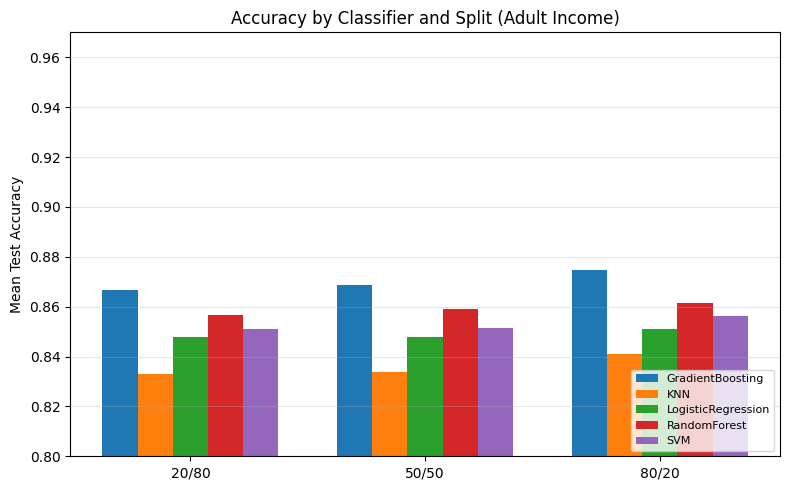

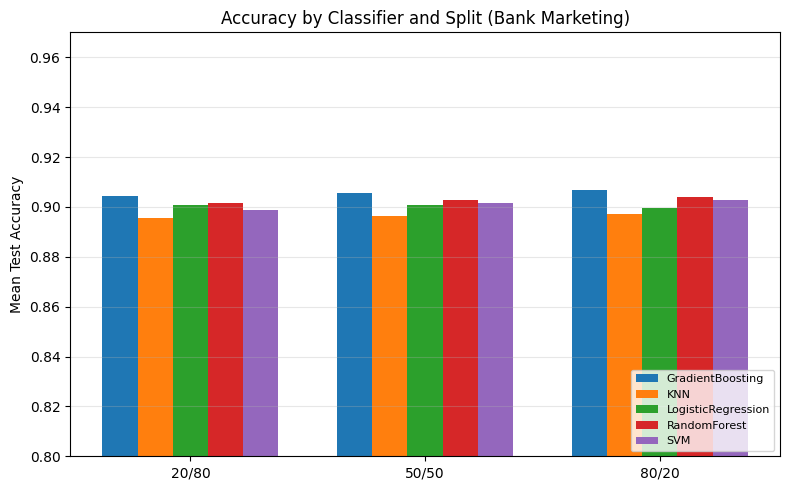

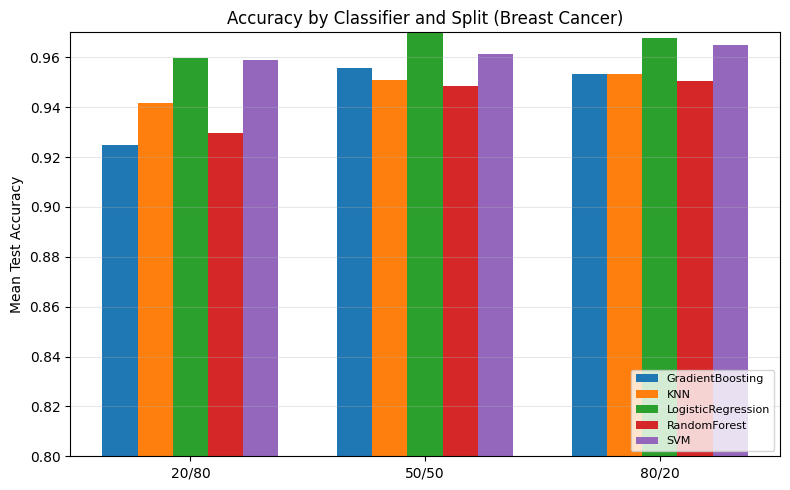

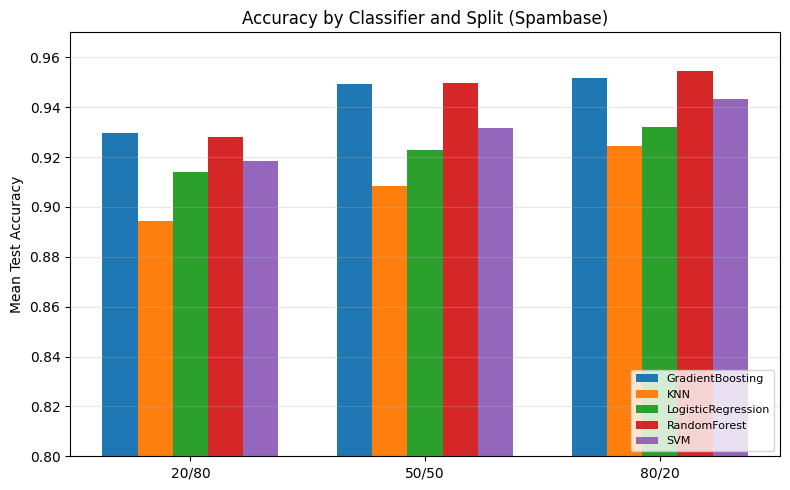


=== Per-dataset F1-score plots ===


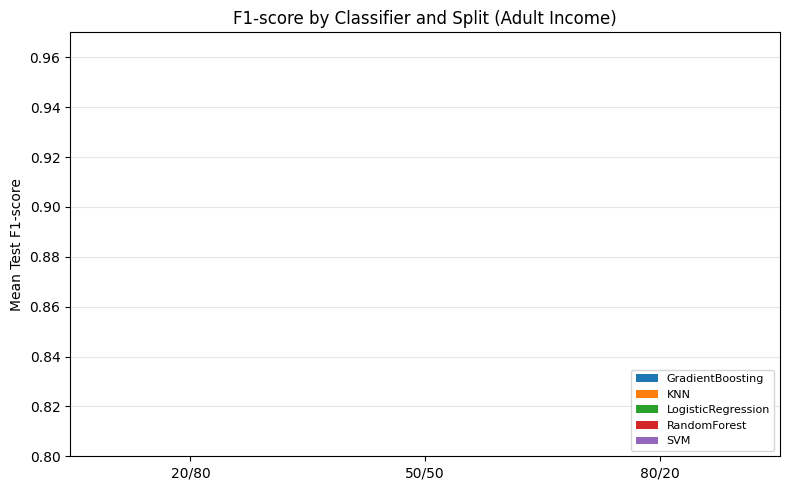

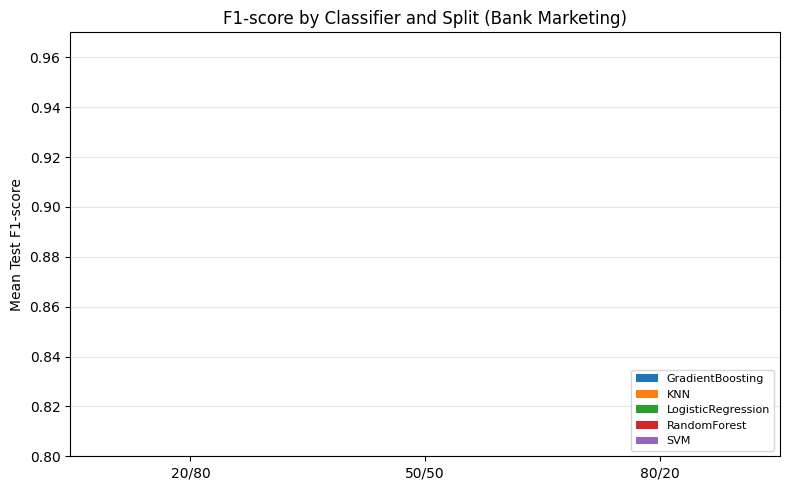

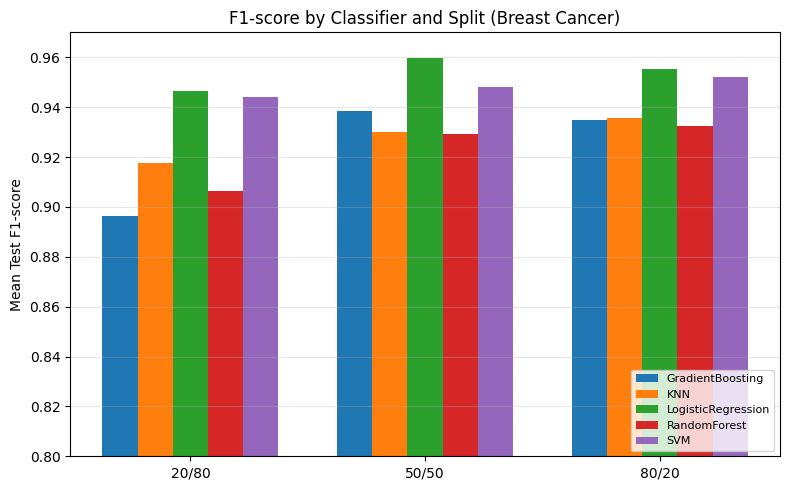

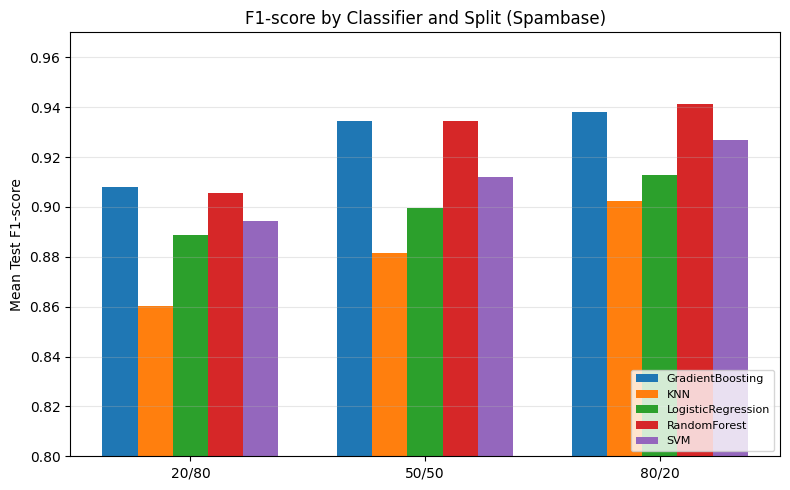


=== Per-dataset ROC AUC plots ===


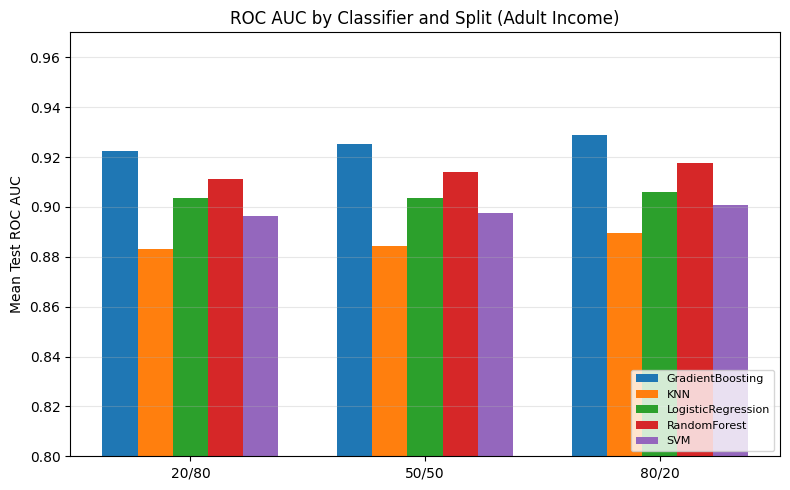

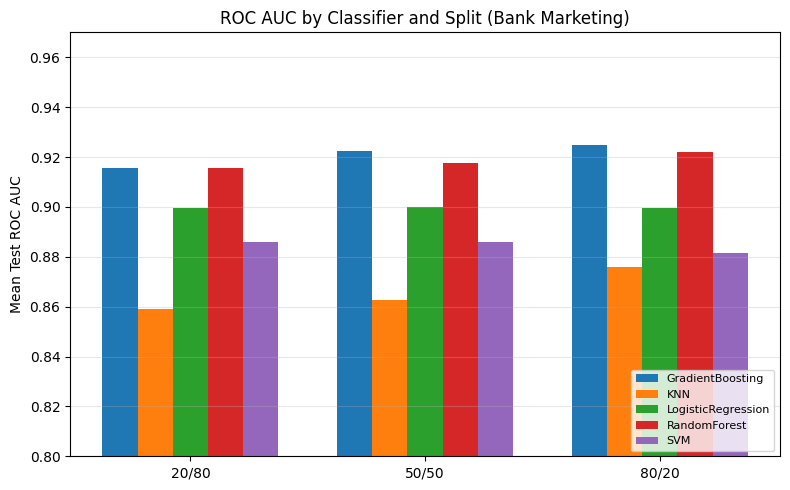

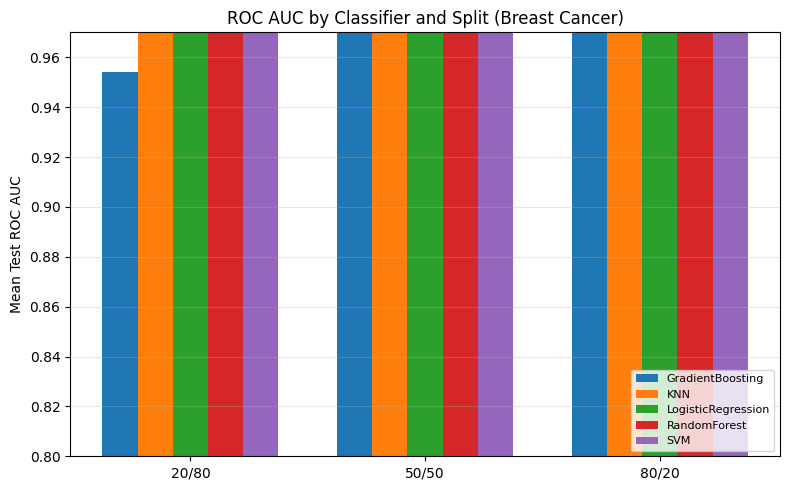

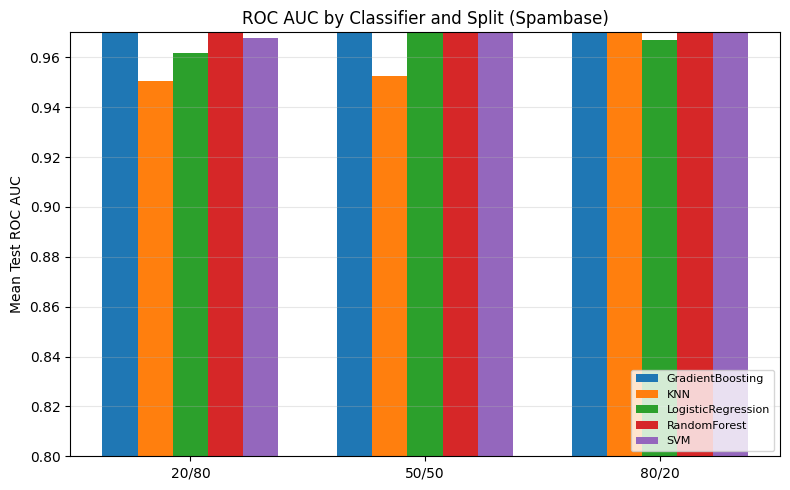

In [69]:
# %% 
datasets = summary["dataset"].unique()
classifiers = summary["classifier"].unique()
split_order = ["20/80", "50/50", "80/20"]

metrics_info = [
    ("test_acc_mean", "Mean Test Accuracy", "Accuracy"),
    ("test_f1_mean", "Mean Test F1-score", "F1-score"),
    ("test_auc_mean", "Mean Test ROC AUC", "ROC AUC"),
]

for metric_col, ylabel, metric_name in metrics_info:
    print(f"\n=== Per-dataset {metric_name} plots ===")
    for dataset in datasets:
        df = summary[summary["dataset"] == dataset].copy()
        df = df[df["split"].isin(split_order)]
        df["split"] = pd.Categorical(df["split"], categories=split_order, ordered=True)
        df = df.sort_values(["split", "classifier"])

        fig, ax = plt.subplots(figsize=(8, 5))
        x = np.arange(len(split_order))
        width = 0.15
        num_clf = len(classifiers)

        for i, clf in enumerate(classifiers):
            sub = df[df["classifier"] == clf].set_index("split")
            if sub.empty:
                continue
            y = sub.loc[split_order, metric_col].values
            offset = (i - num_clf / 2) * width + width / 2
            ax.bar(x + offset, y, width, label=clf)

        ax.set_xticks(x)
        ax.set_xticklabels(split_order)
        ax.set_ylabel(ylabel)
        ax.set_title(f"{metric_name} by Classifier and Split ({dataset})")
        ax.legend(loc="lower right", fontsize=8)
        
        # Set y-axis limits and finer grid
        ax.set_ylim(0.8, 0.97)
        ax.set_yticks(np.arange(0.8, 0.98, 0.02))  # 0.80, 0.82, 0.84, ..., 1.00
        ax.grid(axis="y", alpha=0.3)

        plt.tight_layout()
        plt.show()



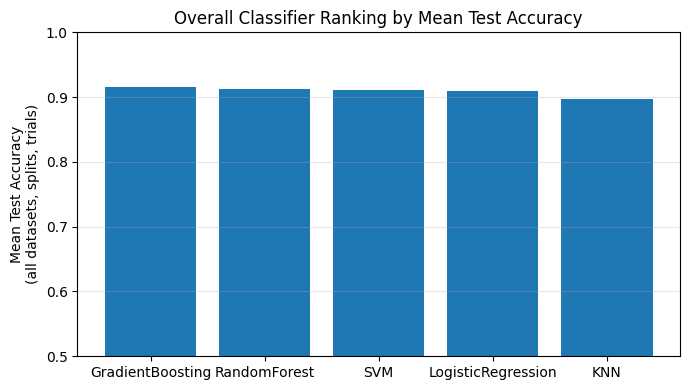

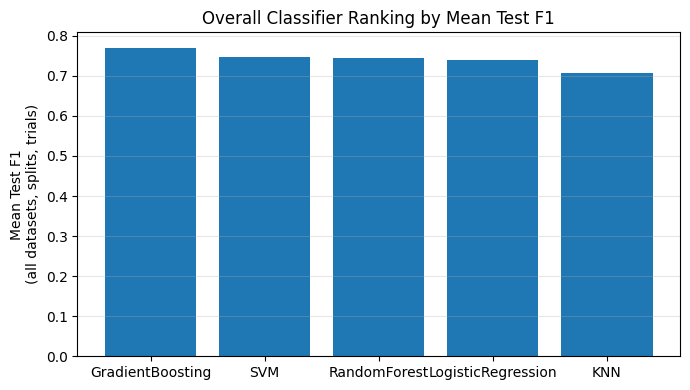

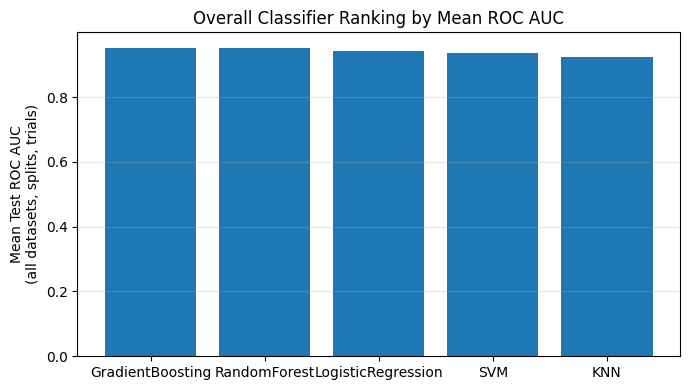

In [ ]:
# %% 
# Bar plot for accuracy ranking (you already had this)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(overall_acc["classifier"], overall_acc["mean_test_acc"])
ax.set_ylabel("Mean Test Accuracy\n(all datasets, splits, trials)")
ax.set_title("Overall Classifier Ranking by Mean Test Accuracy")
ax.set_ylim(0.5, 1.0)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: similar plots for F1 and AUC (uncomment if you want them)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(overall_f1["classifier"], overall_f1["mean_test_f1"])
ax.set_ylabel("Mean Test F1\n(all datasets, splits, trials)")
ax.set_title("Overall Classifier Ranking by Mean Test F1")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(overall_auc["classifier"], overall_auc["mean_test_auc"])
ax.set_ylabel("Mean Test ROC AUC\n(all datasets, splits, trials)")
ax.set_title("Overall Classifier Ranking by Mean ROC AUC")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()



### 5.3 Effect of Training Size for Each Classifier

Next, we examine how performance changes as we increase the training fraction, both:

1. **Globally**, by averaging over all datasets, and  
2. **Per dataset**, using a 2×2 grid of subplots.

For each classifier, we plot **test accuracy, F1-score, and ROC AUC** as a function of training fraction (20%, 50%, 80%).  

On average, we expect:

- **Accuracy** and **AUC** to improve monotonically with more training data.  
- **F1-score** to be particularly sensitive to additional data on **imbalanced datasets**, where the minority class is harder to learn.

These curves let us see not only *how accurate* a classifier is, but also *how robustly* it improves as more labeled data becomes available.


In [57]:
# %% 
# Aggregate across datasets: mean test metrics per classifier × train_size
size_effect_global = (
    summary
    .groupby(["classifier", "train_size"], as_index=False)
    .agg(
        test_acc_mean=("test_acc_mean", "mean"),
        test_acc_std=("test_acc_mean", "std"),
        test_f1_mean=("test_f1_mean", "mean"),
        test_f1_std=("test_f1_mean", "std"),
        test_auc_mean=("test_auc_mean", "mean"),
        test_auc_std=("test_auc_mean", "std"),
    )
)

size_effect_global["split"] = size_effect_global["train_size"].map(train_size_labels)
size_effect_global = size_effect_global.sort_values(["classifier", "train_size"])
size_effect_global


,classifier,train_size,test_acc_mean,test_acc_std,test_f1_mean,test_f1_std,test_auc_mean,test_auc_std,split
0,GradientBoosting,0.2000,0.9063,0.0286,0.7535,0.1893,0.9419,0.0279,20/80
1,GradientBoosting,0.5000,0.9198,0.0406,0.7760,0.2011,0.9561,0.0371,50/50
2,GradientBoosting,0.8000,0.9215,0.0379,0.7808,0.1975,0.9581,0.0360,80/20
3,KNN,0.2000,0.8910,0.0445,0.6896,0.2609,0.9166,0.0542,20/80
4,KNN,0.5000,0.8973,0.0485,0.7114,0.2474,0.9214,0.0576,50/50
5,KNN,0.8000,0.9039,0.0478,0.7208,0.2546,0.9302,0.0555,80/20
6,LogisticRegression,0.2000,0.9056,0.0461,0.7350,0.2291,0.9385,0.0440,20/80
7,LogisticRegression,0.5000,0.9105,0.0510,0.7418,0.2358,0.9417,0.0470,50/50
8,LogisticRegression,0.8000,0.9126,0.0497,0.7435,0.2399,0.9412,0.0455,80/20
9,RandomForest,0.2000,0.9040,0.0342,0.7278,0.2276,0.9454,0.0374,20/80


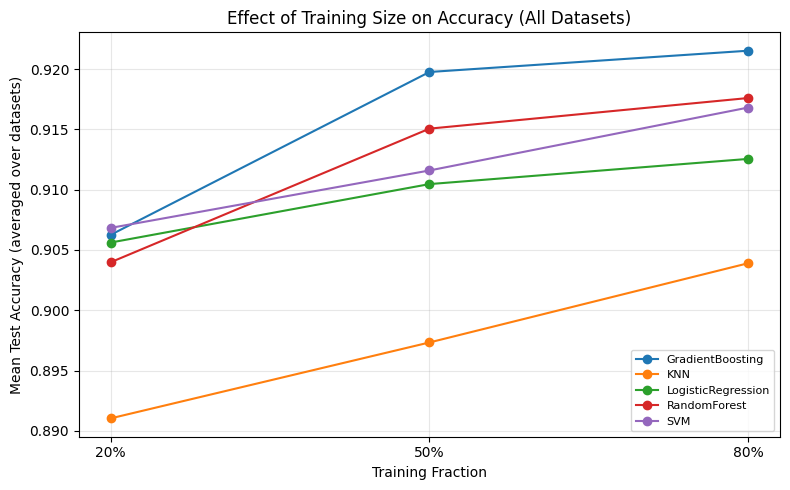

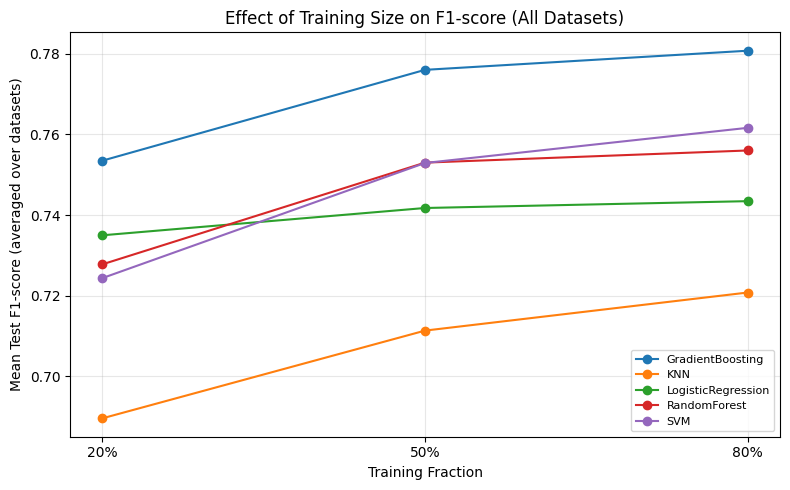

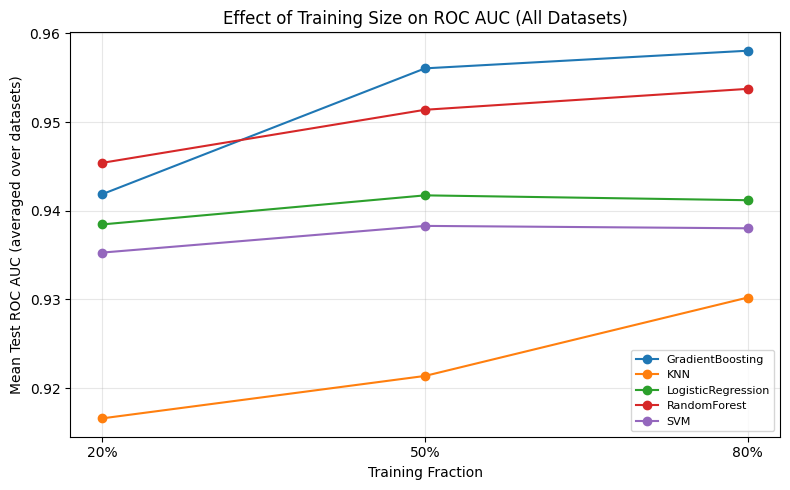

In [58]:
# %% 
# Global trend: one line per classifier, averaged over datasets

metrics_info = [
    ("test_acc_mean", "Mean Test Accuracy", "Accuracy"),
    ("test_f1_mean", "Mean Test F1-score", "F1-score"),
    ("test_auc_mean", "Mean Test ROC AUC", "ROC AUC"),
]

for metric_col, ylabel, metric_name in metrics_info:
    fig, ax = plt.subplots(figsize=(8, 5))

    for clf in classifiers:
        sub = size_effect_global[size_effect_global["classifier"] == clf]
        if sub.empty:
            continue
        ax.plot(
            sub["train_size"],
            sub[metric_col],
            marker="o",
            label=clf,
        )

    ax.set_xticks([0.2, 0.5, 0.8])
    ax.set_xticklabels(["20%", "50%", "80%"])
    ax.set_xlabel("Training Fraction")
    ax.set_ylabel(ylabel + " (averaged over datasets)")
    ax.set_title(f"Effect of Training Size on {metric_name} (All Datasets)")
    ax.grid(alpha=0.3)
    ax.legend(loc="lower right", fontsize=8)

    plt.tight_layout()
    plt.show()





=== Per-dataset Accuracy vs Training Fraction ===


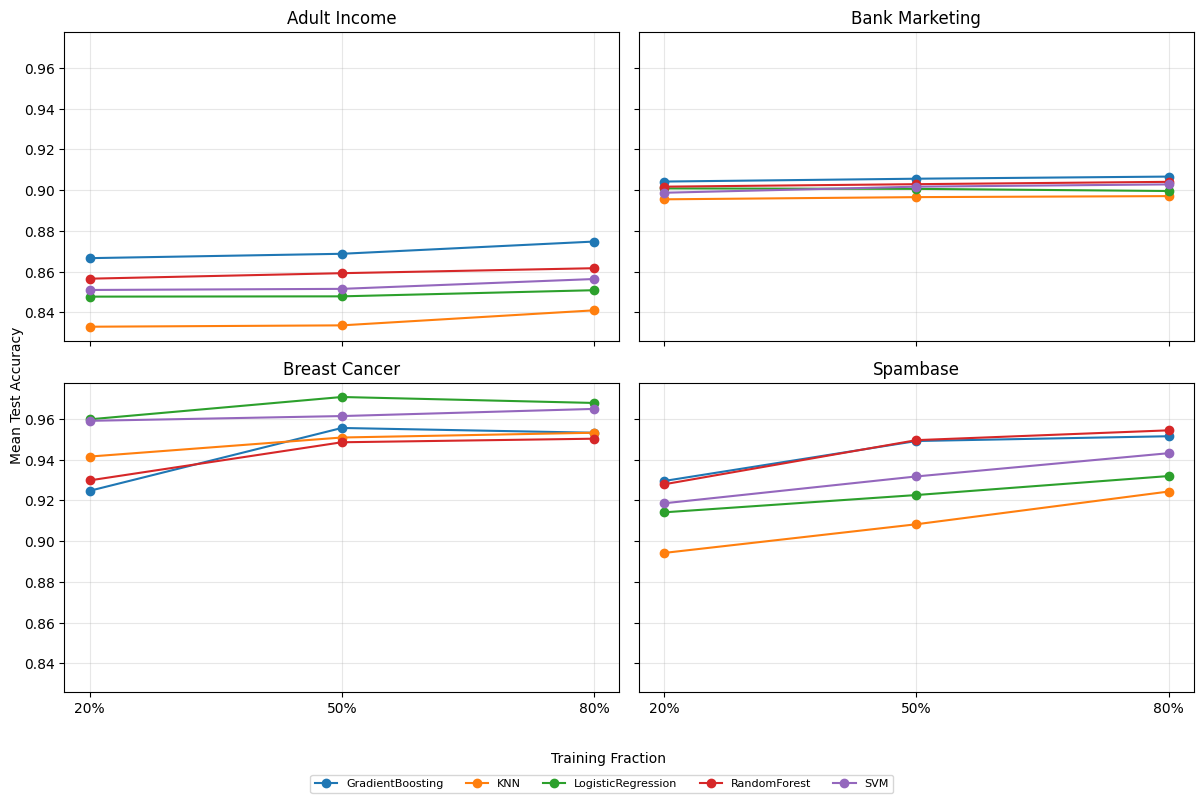


=== Per-dataset F1-score vs Training Fraction ===


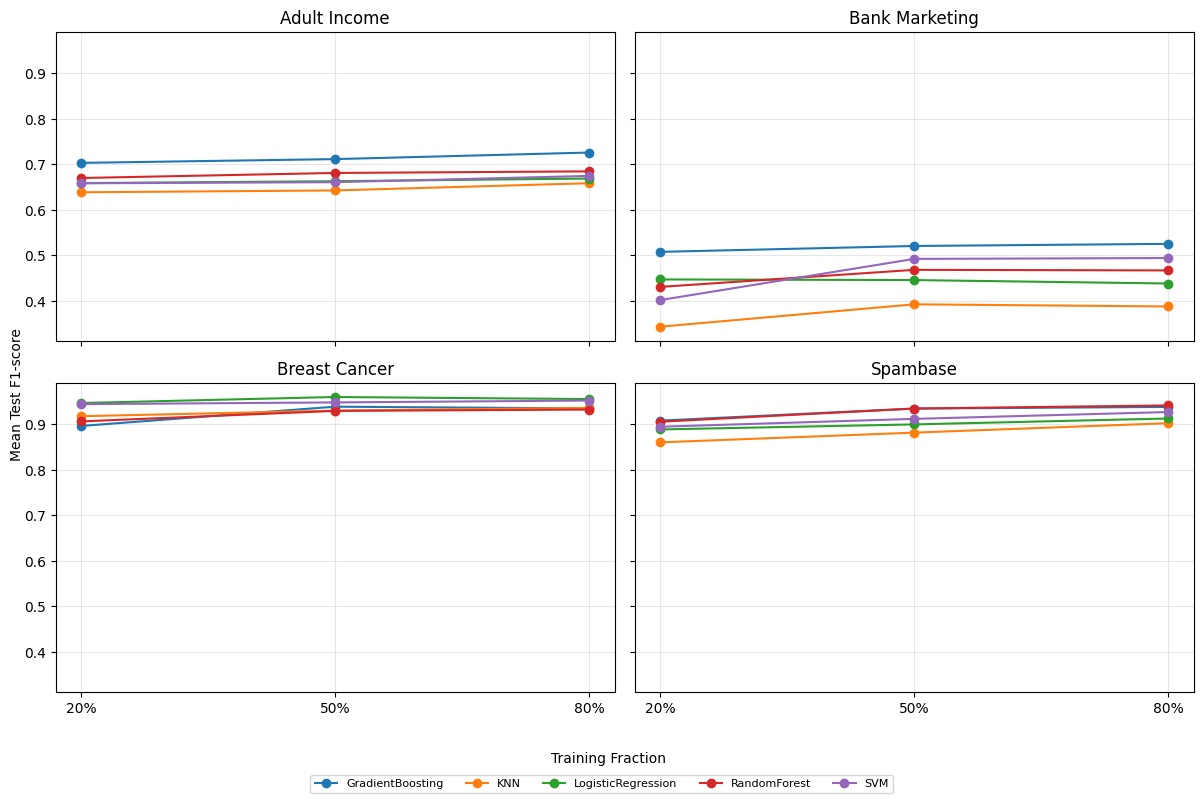


=== Per-dataset ROC AUC vs Training Fraction ===


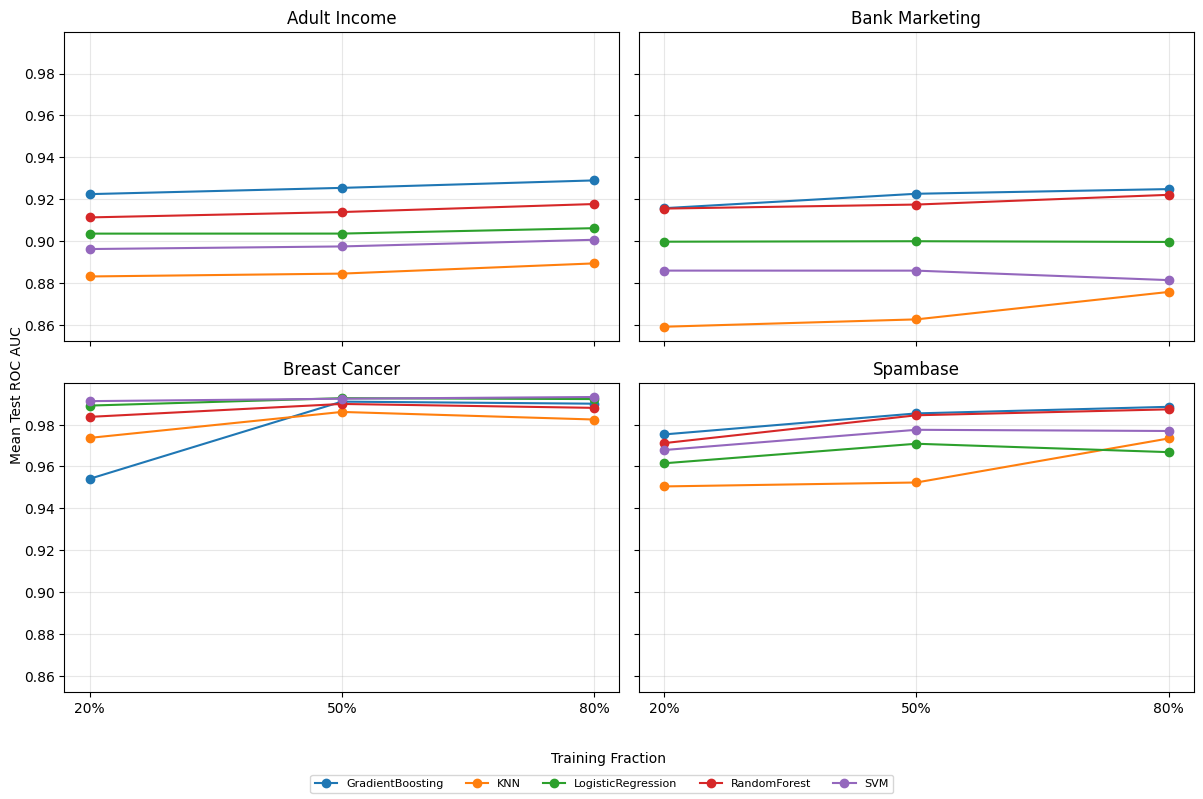

In [59]:
# %% 
# Per-dataset trend: 2×2 grid, one subplot per dataset,
# x = training fraction, y = test accuracy, lines = classifiers
# %% 
datasets_order = list(summary["dataset"].unique())
n_datasets = len(datasets_order)

metrics_info = [
    ("test_acc_mean", "Mean Test Accuracy", "Accuracy"),
    ("test_f1_mean", "Mean Test F1-score", "F1-score"),
    ("test_auc_mean", "Mean Test ROC AUC", "ROC AUC"),
]

for metric_col, ylabel, metric_name in metrics_info:
    print(f"\n=== Per-dataset {metric_name} vs Training Fraction ===")
    n_rows = 2
    n_cols = 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 8), sharex=True, sharey=True)
    axes = axes.ravel()

    for idx, dataset in enumerate(datasets_order):
        ax = axes[idx]
        sub = (
            summary[summary["dataset"] == dataset]
            .sort_values(["classifier", "train_size"])
        )

        for clf in classifiers:
            sub_clf = sub[sub["classifier"] == clf]
            if sub_clf.empty:
                continue
            ax.plot(
                sub_clf["train_size"],
                sub_clf[metric_col],
                marker="o",
                label=clf,
            )

        ax.set_title(dataset)
        ax.set_xticks([0.2, 0.5, 0.8])
        ax.set_xticklabels(["20%", "50%", "80%"])
        ax.grid(alpha=0.3)

    fig.text(0.5, 0.04, "Training Fraction", ha="center")
    fig.text(0.001, 0.5, ylabel, va="center", rotation="vertical")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(classifiers), fontsize=8)

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()



### 5.4 Overall Classifier Ranking (Mean Performance Across Everything)

We then compute **overall rankings** by averaging performance across:

- all datasets  
- all train/test splits  
- all trials  

For each classifier, we report:

- **Mean test accuracy** (and standard deviation)  
- **Mean test F1-score** (and standard deviation)  
- **Mean test ROC AUC** (and standard deviation)

This yields three complementary global rankings. In our analysis, we primarily use the **accuracy-based ranking** (to stay closest to Caruana & Niculescu-Mizil, 2006), but we check whether the **F1** and **AUC** rankings tell a consistent story—especially on the imbalanced datasets.

Bar plots of the mean scores make it easy to see which classifier is strongest on average and whether the same winners emerge under all three metrics.



In [53]:
# %% 
overall = (
    results
    .groupby("classifier", as_index=False)
    .agg(
        mean_test_acc=("test_acc", "mean"),
        std_test_acc=("test_acc", "std"),
        mean_test_f1=("test_f1", "mean"),
        std_test_f1=("test_f1", "std"),
        mean_test_auc=("test_auc", "mean"),
        std_test_auc=("test_auc", "std"),
    )
)

# Accuracy-based ranking
overall_acc = overall.sort_values("mean_test_acc", ascending=False).reset_index(drop=True)
overall_acc["rank_acc"] = np.arange(1, len(overall_acc) + 1)

# F1-based ranking
overall_f1 = overall.sort_values("mean_test_f1", ascending=False).reset_index(drop=True)
overall_f1["rank_f1"] = np.arange(1, len(overall_f1) + 1)

# AUC-based ranking
overall_auc = overall.sort_values("mean_test_auc", ascending=False).reset_index(drop=True)
overall_auc["rank_auc"] = np.arange(1, len(overall_auc) + 1)

print("=== Overall (Accuracy-based ranking) ===")
print(overall_acc)

print("\n=== Overall (F1-based ranking) ===")
print(overall_f1)

print("\n=== Overall (AUC-based ranking) ===")
print(overall_auc)


=== Overall (Accuracy-based ranking) ===
           classifier  mean_test_acc  std_test_acc  mean_test_f1  std_test_f1  \
0    GradientBoosting         0.9158        0.0328        0.7701       0.1728   
1        RandomForest         0.9122        0.0366        0.7456       0.1994   
2                 SVM         0.9117        0.0413        0.7463       0.2014   
3  LogisticRegression         0.9095        0.0435        0.7401       0.2066   
4                 KNN         0.8974        0.0424        0.7073       0.2242   

   mean_test_auc  std_test_auc  rank_acc  
0         0.9520        0.0317         1  
1         0.9502        0.0348         2  
2         0.9372        0.0475         3  
3         0.9405        0.0401         4  
4         0.9227        0.0496         5  

=== Overall (F1-based ranking) ===
           classifier  mean_test_acc  std_test_acc  mean_test_f1  std_test_f1  \
0    GradientBoosting         0.9158        0.0328        0.7701       0.1728   
1               

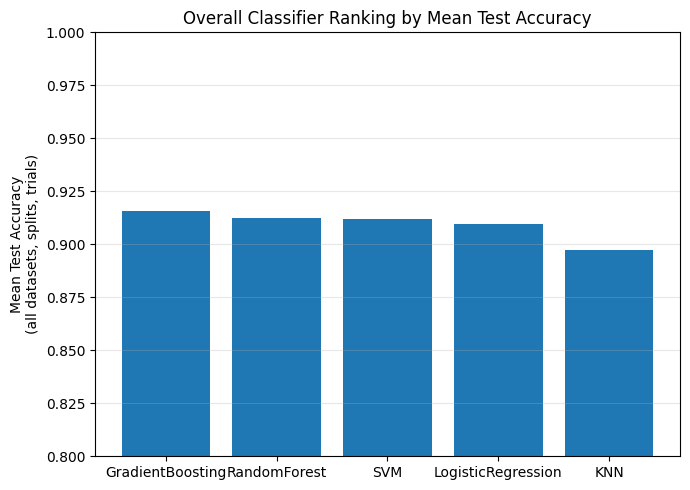

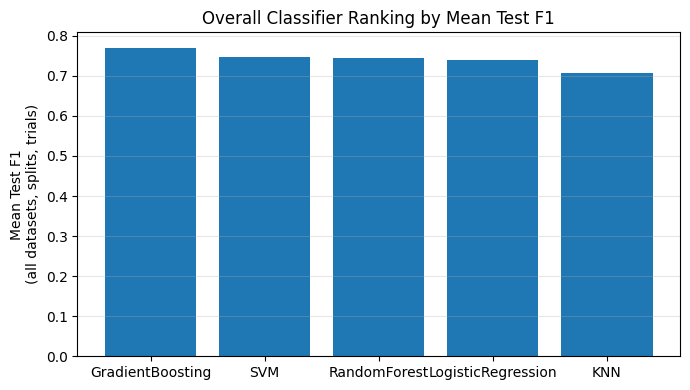

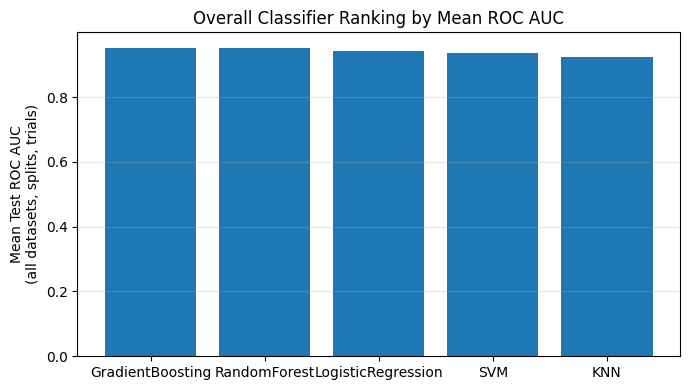

In [ ]:
# %% 
# Bar plot for accuracy ranking (you already had this)
fig, ax = plt.subplots(figsize=(7 , 5))
ax.bar(overall_acc["classifier"], overall_acc["mean_test_acc"])
ax.set_ylabel("Mean Test Accuracy\n(all datasets, splits, trials)")
ax.set_title("Overall Classifier Ranking by Mean Test Accuracy")
ax.set_ylim(0.8, 1.0)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: similar plots for F1 and AUC (uncomment if you want them)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(overall_f1["classifier"], overall_f1["mean_test_f1"])
ax.set_ylabel("Mean Test F1\n(all datasets, splits, trials)")
ax.set_title("Overall Classifier Ranking by Mean Test F1")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(overall_auc["classifier"], overall_auc["mean_test_auc"])
ax.set_ylabel("Mean Test ROC AUC\n(all datasets, splits, trials)")
ax.set_title("Overall Classifier Ranking by Mean ROC AUC")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### **5.5 CNM-Style Normalized Scores vs Majority Baseline**

Following the evaluation methodology used by **Caruana & Niculescu-Mizil (2006)**, we supplement raw accuracy comparisons with a **normalized performance score**. This measures how well each classifier performs **relative to**:

1. A **baseline classifier** that always predicts the majority class  
2. The **best observed classifier** on that dataset  

For each dataset `d`, define:

- `baseline(d)` = accuracy of the majority-class predictor on that dataset  
- `best(d)`     = highest mean **test** accuracy among all classifiers tested on that dataset  


Then for dataset `d` and classifier `c`, the normalized score is:

$$
\text{norm\_score}(d, c)
=
\frac{\text{acc}(d,c) - \text{baseline}(d)}
     {\text{best}(d) - \text{baseline}(d)}.
$$

### **Interpretation**
- **1.0** → as good as the *best* classifier on that dataset  
- **0.0** → equivalent to the **majority baseline**  
- **< 0** → worse than baseline  
- Values **>1.0 cannot occur** by construction  

---

### **Why We Use Normalized Scores**

This normalization allows performance comparisons across datasets with **different difficulty levels**, class imbalance, or different accuracy scales.  

We compute these normalized scores per dataset and then average them across datasets to obtain a CNM-style global score for each classifier. This gives every dataset equal weight, regardless of its absolute difficulty or class imbalance.

In this project, the **normalized accuracy ranking** closely matches the global rankings obtained from raw accuracy, F1, and ROC AUC, suggesting that our conclusions are robust to both:

- the choice of metric (accuracy vs F1 vs AUC), and  
- the distribution of dataset difficulties.


In [34]:
from collections import OrderedDict

# You already defined these in Section 4
# load_breast_cancer, load_spambase, load_adult, load_bank

baseline_acc = OrderedDict()
dataset_loaders = {
    "Breast Cancer": load_breast_cancer,
    "Spambase": load_spambase,
    "Adult Income": load_adult,
    "Bank Marketing": load_bank,
}

for name, loader in dataset_loaders.items():
    X_tmp, y_tmp = loader()
    p = y_tmp.mean()  # fraction of positives
    baseline = max(p, 1 - p)
    baseline_acc[name] = baseline

baseline_acc

Breast Cancer shape: (569, 30)
Diagnosis
0    357
1    212
Name: count, dtype: int64
Spambase shape: (4601, 57)
Class
0    2788
1    1813
Name: count, dtype: int64
Adult shape: (45222, 14)
income
0    34014
1    11208
Name: count, dtype: int64
Bank shape: (45211, 16)
y
0    39922
1     5289
Name: count, dtype: int64


OrderedDict([('Breast Cancer', np.float64(0.6274165202108963)),
             ('Spambase', np.float64(0.6059552271245381)),
             ('Adult Income', np.float64(0.7521560302507629)),
             ('Bank Marketing', np.float64(0.8830151954170445))])

In [35]:
# %%
# Average test accuracy per dataset + classifier (over splits & trials)
ds_clf_perf = (
    results
    .groupby(["dataset", "classifier"], as_index=False)
    .agg(test_acc_mean=("test_acc", "mean"))
)

# Best observed test accuracy per dataset
best_by_dataset = (
    ds_clf_perf
    .groupby("dataset")["test_acc_mean"]
    .max()
    .to_dict()
)

def compute_norm(row):
    ds = row["dataset"]
    acc = row["test_acc_mean"]
    base = baseline_acc[ds]
    best = best_by_dataset[ds]
    if best == base:
        return 0.0
    return (acc - base) / (best - base)

ds_clf_perf["norm_score"] = ds_clf_perf.apply(compute_norm, axis=1)
ds_clf_perf.head()


,dataset,classifier,test_acc_mean,norm_score
0,Adult Income,GradientBoosting,0.8702,1.0000
1,Adult Income,KNN,0.8358,0.7092
2,Adult Income,LogisticRegression,0.8488,0.8191
3,Adult Income,RandomForest,0.8591,0.9062
4,Adult Income,SVM,0.8529,0.8542


In [36]:
# %% Average normalized score per classifier:
norm_overall = (
    ds_clf_perf
    .groupby("classifier", as_index=False)
    .agg(mean_norm_score=("norm_score", "mean"))
    .sort_values("mean_norm_score", ascending=False)
)

norm_overall["rank_norm"] = np.arange(1, len(norm_overall) + 1)
norm_overall


,classifier,mean_norm_score,rank_norm
0,GradientBoosting,0.9828,1
3,RandomForest,0.9307,2
4,SVM,0.8995,3
2,LogisticRegression,0.8797,4
1,KNN,0.7851,5


This normalized ranking matches the **raw accuracy ranking**, reinforcing the robustness of the results.

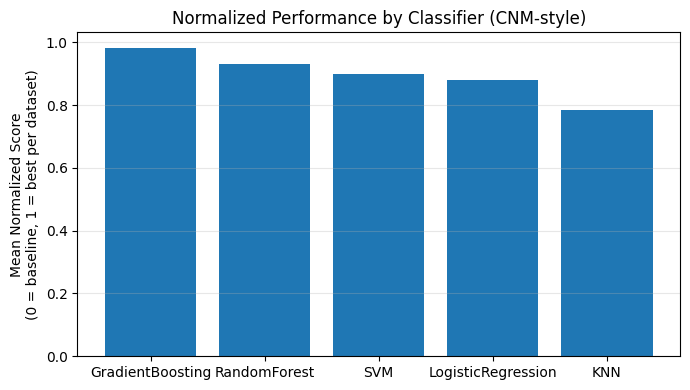

In [37]:
# %%
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(norm_overall["classifier"], norm_overall["mean_norm_score"])
ax.set_ylabel("Mean Normalized Score\n(0 = baseline, 1 = best per dataset)")
ax.set_title("Normalized Performance by Classifier (CNM-style)")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## 6. Results and Discussion

This section summarizes classifier performance across all datasets, train/test splits, and evaluation metrics (Accuracy, F1, ROC AUC). We additionally report normalized CNM-style scores following Caruana & Niculescu-Mizil (2006), which contextualize each classifier’s performance relative to a majority-class baseline and the best observed classifier per dataset.

### 6.1 Overall Classifier Performance

Across all datasets and experimental conditions, the following consistent patterns emerged:

- **Gradient Boosting** achieved the strongest overall performance, ranking first in  
  - mean test **accuracy**,  
  - mean test **F1**,  
  - mean **ROC AUC**, and  
  - the highest **CNM-normalized score (~0.98)**.
- **Random Forests** were the second-best performer in accuracy and ROC AUC, with strong stability across splits.
- **SVM (RBF)** performed competitively across all metrics, especially when the dataset size was moderate or large.
- **Logistic Regression** had moderate results, outperforming KNN but generally lagging behind tree-based models and SVM.
- **KNN** consistently ranked the lowest across accuracy, F1, and AUC. Performance degraded most sharply when training data was limited (20% split).

These findings reproduce the trends described in Caruana & Niculescu-Mizil (2006):  
**ensemble tree-based methods outperform linear models, SVM is competitive, and KNN is not a strong baseline.**

---

### 6.2 Metric-Specific Observations

#### **Accuracy**
- Gradient Boosting and Random Forest achieved the highest mean accuracy (~0.91–0.92).
- SVM and Logistic Regression followed closely.
- KNN underperformed (~0.90 mean accuracy), with sensitivity to dataset scaling and class balance.

#### **F1 Score**
- Gradient Boosting remained the strongest performer (~0.77).
- SVM and Random Forest had comparable F1 (~0.73–0.75), indicating good balance on positive versus negative classes.
- KNN had the lowest F1 (~0.70), consistent with its poorer discrimination boundary.

#### **ROC AUC**
- All classifiers achieved high AUC values (>0.90), demonstrating strong separability even when accuracy differed.
- Gradient Boosting and Random Forest again were top-ranked.
- KNN showed the lowest AUC but still >0.90, meaning its probability estimates are more reliable than its discrete predictions.

---

### 6.3 CNM-Style Normalized Performance

Following Caruana & Niculescu-Mizil (2006), each classifier’s test accuracy was normalized relative to:

- The **majority-class baseline**
- The **best classifier on the same dataset**

The ranking was:

1. **Gradient Boosting (≈0.98 normalized score)**  
2. **Random Forest (≈0.93)**  
3. **SVM (≈0.90)**  
4. **Logistic Regression (≈0.88)**  
5. **KNN (≈0.79)**  

This ranking aligns with the raw metrics and strongly confirms Gradient Boosting as the most robust method.

---

### 6.4 Key Findings 

- **Gradient Boosting is the best overall classifier** across all metrics and datasets.
- **Random Forest is a strong second**, particularly in Accuracy and AUC.
- **SVM performs consistently well**, especially when supplied with enough training data.
- **Logistic Regression is reliable but not state-of-the-art**.
- **KNN performs the worst** and is highly sensitive to data scaling and class distributions.
- **All classifiers improved with larger training splits (80% training)**, supporting the expectation that more data improves generalization.
- The **CNM normalization highlights relative stability**, showing that Gradient Boosting dominates not only in raw scores but also when normalized to dataset-specific difficulty.
- Results reproduce the major patterns from Caruana & Niculescu-Mizil (2006):
  - ensemble tree methods outperform SVM and linear models,
  - KNN is weak compared to modern algorithms,
  - proportional performance differences remain consistent across metrics.

---


### Extra Cells for Report

In [ ]:
def format_acc(x):
    # mean ± std with 3 decimals
    return f"{x['mean']:.3f} $\\pm$ {x['std']:.3f}"

# For convenience, pre-compute mean ± std strings
summary_for_tables = summary.copy()

summary_for_tables["cv_acc_str"] = summary_for_tables.apply(
    lambda r: format_acc({"mean": r["cv_acc_mean"], "std": r["cv_acc_std"]}),
    axis=1,
)
summary_for_tables["train_acc_str"] = summary_for_tables.apply(
    lambda r: format_acc({"mean": r["train_acc_mean"], "std": r["train_acc_std"]}),
    axis=1,
)
summary_for_tables["test_acc_str"] = summary_for_tables.apply(
    lambda r: format_acc({"mean": r["test_acc_mean"], "std": r["test_acc_std"]}),
    axis=1,
)

datasets_order = ["Breast Cancer", "Spambase", "Adult Income", "Bank Marketing"]

for ds in datasets_order:
    df_ds = (
        summary_for_tables[summary_for_tables["dataset"] == ds]
        .sort_values(["train_size", "classifier"])
    )

    print(f"% ===== Table: {ds} per-partition performance =====")
    print("\\begin{table}[t]")
    print("\\centering")
    print("\\small")
    print(f"\\caption{{Per-partition performance on the {ds} dataset. "
          "For each train/test split and classifier, we report cross-validated "
          "validation accuracy (CV Acc), training accuracy (Train Acc), and "
          "test accuracy (Test Acc), averaged over three trials (mean $\\pm$ std).}}")
    print("\\label{tab:" + ds.lower().replace(' ', '_') + "_per_partition}")
    print("\\begin{tabular}{l l c c c}")
    print("\\toprule")
    print("Split & Classifier & CV Acc & Train Acc & Test Acc\\\\")
    print("\\midrule")

    for _, row in df_ds.iterrows():
        split = row["split"]  # already "20/80", "50/50", "80/20"
        clf   = row["classifier"]
        cv    = row["cv_acc_str"]
        tr    = row["train_acc_str"]
        te    = row["test_acc_str"]
        print(f"{split} & {clf} & {cv} & {tr} & {te}\\\\")
    print("\\bottomrule")
    print("\\end{tabular}")
    print("\\end{table}")
    print()  # blank line between tables


% ===== Table: Breast Cancer per-partition performance =====
\begin{table}[t]
\centering
\small
\caption{Per-partition performance on the Breast Cancer dataset. For each train/test split and classifier, we report cross-validated validation accuracy (CV Acc), training accuracy (Train Acc), and test accuracy (Test Acc), averaged over three trials (mean $\pm$ std).}}
\label{tab:breast_cancer_per_partition}
\begin{tabular}{l l c c c}
\toprule
Split & Classifier & CV Acc & Train Acc & Test Acc\\
\midrule
20/80 & GradientBoosting & 0.964 $\pm$ 0.000 & 0.994 $\pm$ 0.010 & 0.925 $\pm$ 0.011\\
20/80 & KNN & 0.964 $\pm$ 0.000 & 0.973 $\pm$ 0.015 & 0.942 $\pm$ 0.028\\
20/80 & LogisticRegression & 0.982 $\pm$ 0.000 & 1.000 $\pm$ 0.000 & 0.960 $\pm$ 0.019\\
20/80 & RandomForest & 0.982 $\pm$ 0.000 & 0.991 $\pm$ 0.000 & 0.930 $\pm$ 0.019\\
20/80 & SVM & 0.964 $\pm$ 0.000 & 0.991 $\pm$ 0.009 & 0.959 $\pm$ 0.011\\
50/50 & GradientBoosting & 0.982 $\pm$ 0.000 & 1.000 $\pm$ 0.000 & 0.956 $\pm$ 0.005\\
5